In [1]:
import networkx as nx
import pandas as pd

In [7]:
# Load data
cities = pd.read_csv("network_nodes_car.csv")          # columns: name, station, lat, lon
connections = pd.read_csv("network_edges_car.csv")  # columns: from, to

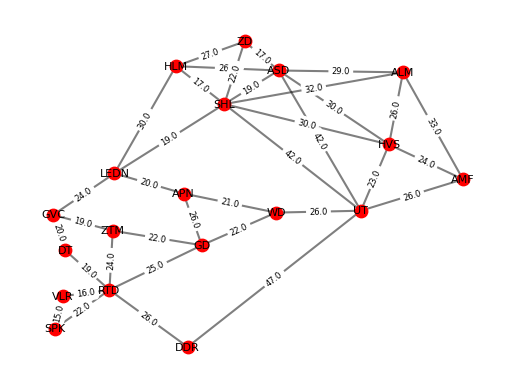

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Make sure lat/lng are numeric
cities["lat"] = pd.to_numeric(cities["lat"], errors="coerce")
cities["lng"] = pd.to_numeric(cities["lng"], errors="coerce")

# Drop rows with missing coordinates
cities = cities.dropna(subset=["lat", "lng"])

# Create the graph
G = nx.Graph()

# Add nodes with coordinates and station info
for _, row in cities.iterrows():
    G.add_node(
        row["name"],
        station=row.get("station", None),
        lat=row["lat"],
        lon=row["lng"]
    )

# Add edges, ensuring no duplicates
seen_edges = set()
for _, row in connections.iterrows():
    a, b = row["from"], row["to"]
    if a in G and b in G and a != b:
        edge = tuple(sorted([a, b]))
        if edge not in seen_edges:
            weight = row.get("time", 1)  # optional: use weight if present
            G.add_edge(a, b, weight=weight)
            seen_edges.add(edge)

# Define positions based on coordinates
pos = {row["name"]: (row["lng"], row["lat"]) for _, row in cities.iterrows()}

# Draw graph nodes and edges
nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.5)
nx.draw_networkx_nodes(G, pos, node_size=80, node_color="red")
nx.draw_networkx_labels(G, pos, font_size=8)

# If edges have weights, add them
if nx.get_edge_attributes(G, "weight"):
    edge_labels = {
        (u, v): f"{data['weight']:.1f}"
        for u, v, data in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.axis("off")
plt.show()